# 04 — Cohort Retention Analysis
Monthly acquisition cohorts: of customers whose **first** purchase was in month X, what share purchased again N months later?

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
PINK, DARK, GREY = "#e75480", "#2d2d2d", "#999999"
RAW, PROC = "../data/raw/", "../data/processed/"
orders = pd.read_csv(PROC + "orders_clean.csv", parse_dates=["created_at", "order_date", "order_month"])
valid = orders[(~orders.cancelled) & (orders.total > 500)].copy()
daily = pd.read_csv(RAW + "daily_sales.csv", parse_dates=["day"])
fmt_pkr = mtick.FuncFormatter(lambda x, _: f"{x/1000:,.0f}K")

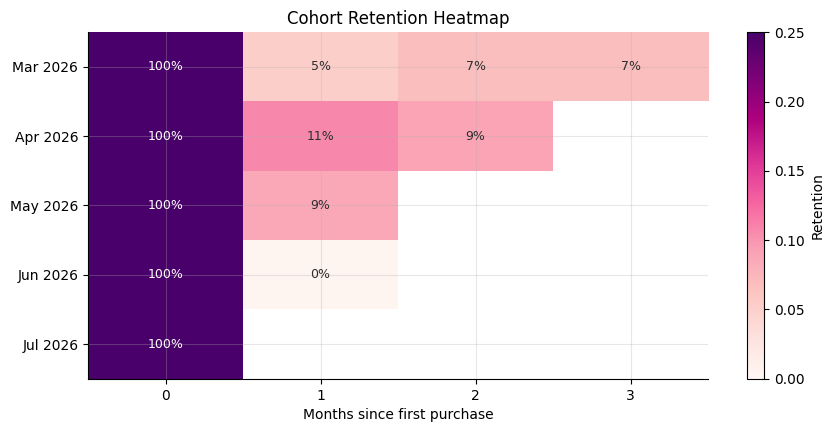

In [2]:
cohort = pd.read_csv(PROC + "cohort_retention.csv", parse_dates=["cohort_month"])
piv = cohort.pivot(index="cohort_month", columns="months_since", values="retention_rate")
piv.index = piv.index.strftime("%b %Y")
fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(piv.values, cmap="RdPu", vmin=0, vmax=.25, aspect="auto")
ax.set_xticks(range(piv.shape[1]), piv.columns); ax.set_yticks(range(len(piv)), piv.index)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0%}", ha="center", va="center",
                    color="white" if (j==0 or v>.15) else DARK, fontsize=9)
ax.set_xlabel("Months since first purchase"); ax.set_title("Cohort Retention Heatmap")
plt.colorbar(im, label="Retention"); plt.show()

In [3]:
sizes = cohort[cohort.months_since==0][["cohort_month","cohort_size"]].set_index("cohort_month")
m1 = cohort[cohort.months_since==1].set_index("cohort_month").retention_rate
summary = sizes.join(m1.rename("month1_retention"))
summary.index = summary.index.strftime("%b %Y"); summary.round(3)

,cohort_size,month1_retention
cohort_month,,
Mar 2026,59,0.051
Apr 2026,56,0.107
May 2026,151,0.086
Jun 2026,257,0.004
Jul 2026,8,NaN


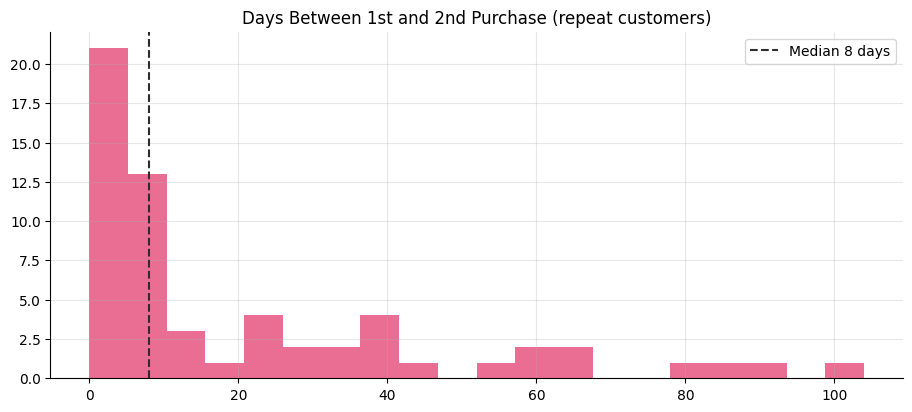

60 repeat customers | median gap 8 days | 75th pct 33 days


In [4]:
# Time between 1st and 2nd purchase for repeat customers
rep = valid.sort_values("created_at").groupby("customer").order_date.apply(list)
gaps = [(o[1]-o[0]).days for o in rep if len(o) > 1]
plt.hist(gaps, bins=20, color=PINK, alpha=.85)
plt.axvline(np.median(gaps), color=DARK, ls="--", label=f"Median {np.median(gaps):.0f} days")
plt.title("Days Between 1st and 2nd Purchase (repeat customers)"); plt.legend(); plt.show()
print(f"{len(gaps)} repeat customers | median gap {np.median(gaps):.0f} days | 75th pct {np.percentile(gaps,75):.0f} days")

### Findings
- Month-1 retention: **Mar 5.1%, Apr 10.7%, May 8.6%** (June's 0.4% is censored — its month-1 window has barely started). ~5–10% is typical for a young social-driven fashion D2C brand.
- Repeat purchases happen **fast**: median gap between 1st and 2nd purchase is just **8 days** (75th percentile: 33 days). If a customer hasn't re-ordered within a month, they've likely lapsed → trigger the re-engagement message around **day 10–14**, not day 30.
- The June cohort (257 new customers) is the big retention opportunity: lifting its month-1 retention to May's 8.6% ≈ +22 repeat orders ≈ **+PKR 90K** at current AOV.
- 60 repeat customers already exist — a named VIP list this small can be managed manually via WhatsApp.